<a href="https://colab.research.google.com/github/aaronhowellai/machine-learning-projects/blob/aaronhowellai-patch-1/large%20language%20models/Gemini%20Developer%20API%2C%20LLMs%2C%20LMMs%20(ft%20Diffusion).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 **Testing Gemini API 🇬**
* A notebook of my implementation of guidance and tutorials from [Get_started.ipynb](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb#scrollTo=KVQZitGE7EbW) on how to use the Gemini API for fine-tuning, configuration, text generation, multimodal generation and more.
  * [Gemini Developer API](https://ai.google.dev/gemini-api/docs#python)
  * [Gemini API libraries](https://ai.google.dev/gemini-api/docs/libraries)
  * [Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb)
  * [Google GenAI SDK](https://github.com/googleapis/python-genai)
  * [Spatial Understanding](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb)

## **Gemini 2.5 Flash Lite API Test**

In [1]:
# import packages
from google.colab import userdata
from google import genai, generativeai
from google.genai import types
from IPython.display import Markdown
import requests
import pathlib
from PIL import Image
from pydantic import TypeAdapter

## **Guide to APIs**
* Graphic on APIs I created in Google Slides, taken from my GitHub profile

![API Image](https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/machine%20learning%20concepts/application%20programming%20interface%20(api).png)

In [2]:
# store the API key in colab as a secret
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

client = genai.Client(api_key=GEMINI_API_KEY)

## **Choose a Gemini Model**

In [3]:
MODEL_ID = "gemini-2.5-flash-lite" # @param ["gemini-2.5-flash-lite", "gemini-2.5-flash", "gemini-2.5-pro"] {"allow-input":true, isTemplate: true}

## **Send text prompts**

* Use the `generate_content` method to generate responses to your prompts.

In [4]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="How do you learn how to beat technical assessments for ai intern roles. Answer in one line."
)

Markdown(response.text)

Practice coding, understand ML fundamentals, and study common algorithm and data structure problems.

## **Calculate Tokens**
* Tokens are the basic input to the gemini and other LLMs.

In [5]:
response = client.models.count_tokens(
    model=MODEL_ID,
    contents="How do you learn how to beat technical assessments for ai intern roles. Answer in one line."
)
print(response)

total_tokens=20 cached_content_token_count=None


## **Multimodal Prompts**
* Multimodal prompts can also be generated including the follwoing in prompts:
  * PDFs
  * Images
  * Audio
  * Video

### **Download an Image, Save it as Byte Stream, write to a local file**

In [6]:
IMG = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/black.jpg"
img_bytes = requests.get(IMG).content

img_path = pathlib.Path('black.jpg')
img_path.write_bytes(img_bytes)

2343619

### **Open Saved Image, Create Thumbnail, Generate Blog From It**

In [7]:
MODEL_ID = "gemini-2.5-flash" # @param ["gemini-2.5-flash-lite", "gemini-2.5-flash", "gemini-2.5-pro"] {"allow-input":true, isTemplate: true}

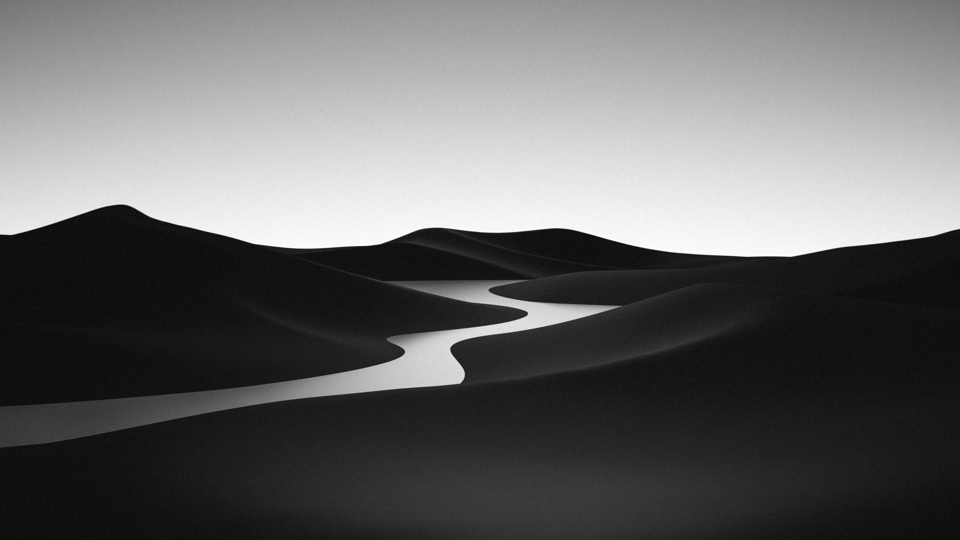

**The Quiet River of Lost Things**

Black dunes, silent sleep.
A white river, stark and strange,
Winds through darkest sand.

It flows from nowhere,
Leading nowhere I yet know.
A memory's trace.

Perhaps a dream's path,
Whispering of what came next.
Just the vast silence,
And this pale, silver quest.

In [8]:
image = Image.open(img_path)
image.thumbnail([960,715])

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        image,
        "Write a 10 line haiku blog post based on the image attached in the style of Murakami, with a title"
    ]
)

display(image)
Markdown(response.text)

## **Configure Model Parameters In Prompts**

In [9]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="Write a 20 line short story in Japanese about getting stuck in the rain on the way home from work in the style of Murakami. Use an emboldened title also.",
    config=types.GenerateContentConfig(
        temperature=0.3,
        top_p=0.85,
        top_k=15,
        candidate_count=1,
        seed=5,
        stop_sequences=['STOP!'],
        presence_penalty=0.0,
        frequency_penalty=0.0
    )
)

Markdown(response.text)

**雨の記憶**

会社を出たのは、いつもより少し遅い時間だった。
空は鉛色で、湿った空気が肌にまとわりつく。
駅へ向かう途中、最初の雨粒が頬を打った。
それは予兆もなく、突然の出来事だった。
あっという間に、アスファルトは黒い鏡になった。
傘は持っていない。いつものことだ。
近くのコンビニの軒下で、立ち止まる。
人々が慌ただしく通り過ぎるのを、ぼんやりと眺めた。
雨音は、まるで古いジャズのドラムソロのようだった。
遠くで、誰かが「雨だ」と呟いた。
その声は、雨音に吸い込まれて消えた。
ポケットを探ると、冷たくなった小銭が数枚。
何も買わずに、ただそこに立っていた。
時間は、雨粒のように地面に染み込んでいく。
ふと、昔飼っていた猫のことを思い出した。
彼女も雨の日は、窓の外をじっと見ていたっけ。
どれくらいそうしていただろう。
雨脚は少し弱まったようだった。
僕は、濡れた道をゆっくりと歩き出した。

### **Configure Safety Filters**
* The Gemini API allows for content restriction and safety filters across several categories.
```
prompt = """
Say a potentially unpopular opinion using British humour in one line about Londoners...
"""
```

In [10]:
prompt = """
Say a potentially unpopular opinion using British humour in one line about Londoners...
"""

safety_settings = [
    types.SafetySetting(
        category='HARM_CATEGORY_DANGEROUS_CONTENT',
        threshold='BLOCK_ONLY_HIGH'
    )
]

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        safety_settings=safety_settings,
    ),
)

Markdown(response.text)

"Bless their cotton socks, Londoners truly believe anywhere beyond the M25 is just 'the North' and likely doesn't have a decent flat white."

### **Configure an Interactive Conversation**
* `chat.send_message` to send a message and receive a response.

In [11]:
system_instruction = """
You are a 10x software engineer and a premium coding assistant.
You are able to produce expert code in any programming language.
"""

chat_config = types.GenerateContentConfig(
    system_instruction=system_instruction,
)

chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
)

In [12]:
response = chat.send_message("Solve a small Math problem in Haskell")
Markdown(response.text)

Alright, let's solve a small, classic math problem in Haskell: **calculating the Nth Fibonacci number**.

The Fibonacci sequence is defined as follows:
*   F(0) = 0
*   F(1) = 1
*   F(n) = F(n-1) + F(n-2) for n > 1

This problem is excellent for demonstrating Haskell's elegance in handling recursive definitions.

---

### Haskell Solution: Nth Fibonacci Number

```haskell
-- | Calculates the Nth Fibonacci number.
--   The sequence starts with F(0) = 0, F(1) = 1.
--   This is a direct recursive implementation.
fib :: Int -> Int
fib 0 = 0                  -- Base case: The 0th Fibonacci number is 0
fib 1 = 1                  -- Base case: The 1st Fibonacci number is 1
fib n
  | n < 0     = error "Fibonacci is not defined for negative numbers"
  | otherwise = fib (n - 1) + fib (n - 2) -- Recursive step: Sum of the two preceding numbers

-- You can test this in GHCi or by compiling a file.
-- Example usage:
-- main :: IO ()
-- main = do
--   putStrLn $ "Fib(0) = " ++ show (fib 0)
--   putStrLn $ "Fib(1) = " ++ show (fib 1)
--   putStrLn $ "Fib(2) = " ++ show (fib 2)
--   putStrLn $ "Fib(5) = " ++ show (fib 5)
--   putStrLn $ "Fib(10) = " ++ show (fib 10)
--   putStrLn $ "Fib(20) = " ++ show (fib 20)
--   -- putStrLn $ "Fib(40) = " ++ show (fib 40) -- This will be very slow due to re-computation!
```

---

### Explanation:

1.  **Type Signature (`fib :: Int -> Int`)**:
    *   This line declares the type of our function `fib`. It takes an `Int` (integer) as input and returns an `Int` as output.

2.  **Base Cases (`fib 0 = 0`, `fib 1 = 1`)**:
    *   Haskell's pattern matching makes defining base cases incredibly natural.
    *   When `fib` is called with `0`, it immediately returns `0`.
    *   When `fib` is called with `1`, it immediately returns `1`.
    *   These are crucial to stop the recursion and provide the initial values.

3.  **Error Handling (`| n < 0 = error "..."`)**:
    *   While the mathematical definition typically applies to non-negative integers, it's good practice to handle invalid inputs. This guard clause throws an error if a negative number is provided.

4.  **Recursive Step (`fib n = fib (n - 1) + fib (n - 2)`)**:
    *   This is the heart of the Fibonacci definition directly translated into code.
    *   If `n` is neither `0` nor `1` (and not negative), the function calls itself twice: once for `n-1` and once for `n-2`. The results of these recursive calls are then summed.

### How to Run (using GHCi):

1.  Save the code above into a file named `Fibonacci.hs`.
2.  Open your terminal or command prompt and navigate to the directory where you saved the file.
3.  Launch GHCi (the Haskell interactive environment):
    ```bash
    ghci
    ```
4.  Load your file into GHCi:
    ```
    :l Fibonacci.hs
    ```
5.  Now you can call the `fib` function:
    ```haskell
    > fib 0
    0
    > fib 1
    1
    > fib 2
    1
    > fib 3
    2
    > fib 5
    5
    > fib 10
    55
    > fib 20
    6765
    > fib (-5)
    *** Exception: Fibonacci is not defined for negative numbers
    ```

---

**Note on Efficiency:**
While this direct recursive implementation is beautifully simple and mirrors the mathematical definition, it's highly inefficient for larger `n` (e.g., `n > 30-35`). This is because it re-computes the same Fibonacci numbers many, many times (e.g., `fib 5` computes `fib 3` and `fib 2`, and `fib 4` also computes `fib 3` and `fib 2`, leading to redundant calculations).

For a more performant solution in Haskell, you would typically use:
1.  **Memoization**: Using a `Data.Map` or `Data.Array` to store previously computed values.
2.  **An iterative approach**: Using `foldl` or a custom loop that keeps track of the previous two numbers.
3.  **Tail recursion**: Though less direct for `fib(n-1) + fib(n-2)`.
4.  **An infinite list**: Haskell's lazy evaluation allows defining the entire Fibonacci sequence as an infinite list, and then just taking the Nth element:
    ```hachkell
    fibs :: [Integer]
    fibs = 0 : 1 : zipWith (+) fibs (tail fibs)

    fibN :: Int -> Integer
    fibN n = fibs !! n
    ```
    This last one is often considered the "Haskell way" for its elegance and efficiency, as each number is computed only once.

But for a "small math problem" demonstrating basic recursion, the first direct approach is perfect!

In [13]:
response = chat.send_message("Now do something super small in CUDA")
Markdown(response.text)

Okay, let's do something super small in CUDA. The "Hello World" of parallel computing is typically **Vector Addition**.

It demonstrates:
1.  **Host (CPU) code** allocating memory on the Device (GPU).
2.  **Copying data** from Host to Device.
3.  **Launching a Kernel** (GPU function) on the Device.
4.  **Copying results** from Device to Host.
5.  **Freeing Device memory**.

We'll add two vectors, `A` and `B`, element-wise, to produce a third vector `C` (`C[i] = A[i] + B[i]`).

---

### CUDA C++ Solution: Vector Addition

Save this as `vector_add.cu`

```cpp
#include <iostream>  // For input/output (e.g., std::cout)
#include <vector>    // For std::vector on the host
#include <numeric>   // For std::iota (to initialize vectors easily)
#include <cuda_runtime.h> // For CUDA API functions (cudaMalloc, cudaMemcpy, etc.)

// CUDA Kernel: Performs element-wise vector addition on the GPU
// __global__ keyword indicates this function runs on the GPU
// and can be called from the CPU (host).
__global__ void vecAdd(float* A, float* B, float* C, int N) {
    // Calculate the global index for the current thread
    // blockIdx.x: x-dimension index of the current block in the grid
    // blockDim.x: x-dimension size of each block (number of threads per block)
    // threadIdx.x: x-dimension index of the current thread within its block
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // Ensure the thread does not go out of bounds of the array
    // This is important if N is not a multiple of (gridDim.x * blockDim.x)
    if (idx < N) {
        C[idx] = A[idx] + B[idx];
    }
}

int main() {
    // 1. Define problem size
    const int N = 1 << 20; // 2^20 elements (approx 1 million)
    const size_t bytes = N * sizeof(float);

    // 2. Allocate Host (CPU) memory
    std::vector<float> h_a(N); // Input vector A
    std::vector<float> h_b(N); // Input vector B
    std::vector<float> h_c(N); // Output vector C (to store results from GPU)

    // Initialize host input vectors
    // A[i] = i, B[i] = i * 2.0
    std::iota(h_a.begin(), h_a.end(), 0); // Fills with 0, 1, 2, ...
    for (int i = 0; i < N; ++i) {
        h_b[i] = i * 2.0f;
    }

    std::cout << "Vector addition on CUDA for " << N << " elements." << std::endl;

    // 3. Allocate Device (GPU) memory
    float *d_a, *d_b, *d_c; // Pointers to device memory
    // cudaMalloc allocates memory on the device
    cudaMalloc(&d_a, bytes);
    cudaMalloc(&d_b, bytes);
    cudaMalloc(&d_c, bytes);

    // 4. Copy data from Host to Device
    // cudaMemcpy(destination, source, size, direction)
    cudaMemcpy(d_a, h_a.data(), bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b.data(), bytes, cudaMemcpyHostToDevice);

    // 5. Configure Kernel Launch Parameters
    // Determine the number of threads per block and blocks per grid.
    // A common block size is 256 or 512.
    int blockSize = 256;
    // Calculate the number of blocks needed to cover all N elements.
    // (N + blockSize - 1) / blockSize performs a ceiling division.
    int numBlocks = (N + blockSize - 1) / blockSize;

    std::cout << "Launching kernel with " << numBlocks << " blocks and "
              << blockSize << " threads per block." << std::endl;

    // 6. Launch the Kernel on the Device
    // The <<<numBlocks, blockSize>>> syntax is the kernel launch configuration.
    vecAdd<<<numBlocks, blockSize>>>(d_a, d_b, d_c, N);

    // Check for any errors during kernel execution (optional but good practice)
    cudaError_t err = cudaGetLastError();
    if (err != cudaSuccess) {
        std::cerr << "CUDA Error after kernel launch: " << cudaGetErrorString(err) << std::endl;
        return 1;
    }
    // Synchronize to ensure the kernel has finished before copying data back.
    cudaDeviceSynchronize();

    // 7. Copy results from Device back to Host
    cudaMemcpy(h_c.data(), d_c, bytes, cudaMemcpyDeviceToHost);

    // 8. Verify the results (optional)
    bool success = true;
    for (int i = 0; i < 10; ++i) { // Check first 10 elements
        float expected = h_a[i] + h_b[i];
        if (h_c[i] != expected) {
            std::cerr << "Verification failed at index " << i
                      << ": Expected " << expected << ", Got " << h_c[i] << std::endl;
            success = false;
            break;
        }
    }
    if (success) {
        std::cout << "Verification PASSED for first 10 elements." << std::endl;
    } else {
        std::cout << "Verification FAILED." << std::endl;
    }

    // 9. Free Device memory
    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);

    std::cout << "CUDA operations complete." << std::endl;

    return 0;
}
```

---

### How to Compile and Run:

You'll need the NVIDIA CUDA Toolkit installed on your system.
Use the `nvcc` (NVIDIA CUDA Compiler) to compile `.cu` files.

1.  **Open a terminal or command prompt.**
2.  **Navigate to the directory** where you saved `vector_add.cu`.
3.  **Compile:**
    ```bash
    nvcc vector_add.cu -o vector_add
    ```
    (On Windows, you might need to ensure `nvcc` is in your PATH, and you might get `vector_add.exe`).

4.  **Run:**
    ```bash
    ./vector_add
    ```
    (On Windows: `vector_add.exe`)

---

### Expected Output:

```
Vector addition on CUDA for 1048576 elements.
Launching kernel with 4096 blocks and 256 threads per block.
Verification PASSED for first 10 elements.
CUDA operations complete.
```

---

### Breakdown of "Super Small" CUDA Elements:

*   **`__global__`:** Marks a function as a CUDA kernel, meaning it runs on the GPU and can be called from the CPU.
*   **`blockIdx.x`, `blockDim.x`, `threadIdx.x`:** These built-in variables are crucial for identifying each unique thread within the parallel grid. They allow each thread to compute its specific portion of the data (in this case, `C[idx]`).
*   **`cudaMalloc()`:** Allocates memory directly on the GPU's global memory.
*   **`cudaMemcpy()`:** Transfers data between host (CPU) and device (GPU) memory. The last argument specifies the direction (`cudaMemcpyHostToDevice`, `cudaMemcpyDeviceToHost`).
*   **`<<<numBlocks, blockSize>>>`:** This is the *kernel launch configuration*. It tells the CUDA runtime how many blocks of threads (`numBlocks`) and how many threads per block (`blockSize`) to use when executing the `vecAdd` kernel.
*   **`cudaFree()`:** Deallocates memory previously allocated on the device.
*   **`cudaDeviceSynchronize()`:** Blocks the CPU thread until all previously launched CUDA kernels on the device have completed. Essential before reading results back to the CPU.

This example is the absolute minimum to demonstrate data transfer, parallel execution on the GPU, and result retrieval.

## **Save & Restore a Conversation**

In [14]:
# Chat history is a list of Content objects. A TypeAdapter can convert to and from
# these Pydantic types.
history_adapter = TypeAdapter(list[types.Content])

# Use the chat object from the previous section.
chat_history = chat.get_history()

# Convert to a JSON list.
json_history = history_adapter.dump_json(chat_history)

In [15]:
# Convert the JSON back to the Pydantic schema.
history = history_adapter.validate_json(json_history)

# Now load a new chat session using the JSON history.
new_chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
    history=history,
)

response = new_chat.send_message("What was the name of the function again?")
Markdown(response.text)

The name of the CUDA kernel function from the example was `vecAdd`.

## **Generate JSON**
* Possible due to **controlled generation** in the Gemini API (constrained to structured format)

In [16]:
from pydantic import BaseModel
import json

class Recipe(BaseModel):
  recipe_name: str
  recipe_description: str
  recipe_ingredients: list[str]

response = client.models.generate_content(
    model=MODEL_ID,
    contents="""
    Generate a small library cookbook for prompt engineering practices from the perspective of a software engineer.
    """,
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=Recipe
    )
)

print(json.dumps(json.loads(response.text), indent=4))

{
    "recipe_name": "The Software Engineer's Prompt Engineering Cookbook",
    "recipe_description": "A practical guide for software engineers to approach prompt engineering with the rigor of code development. This cookbook emphasizes systematic design, testing, and maintenance of prompts to ensure robust and reliable AI interactions, treating prompts as critical components of the software architecture.",
    "recipe_ingredients": [
        "Clearly Defined Objectives and Constraints",
        "Structured Input Context (e.g., JSON, XML)",
        "Specific Output Format Requirements (e.g., JSON Schema, Markdown)",
        "Role-Playing and Persona Assignment for LLM",
        "Iterative Prompt Refinement and A/B Testing",
        "Version Control for Prompt Management",
        "Automated Prompt Evaluation and Test Cases",
        "Token Economy and Performance Monitoring",
        "Error Handling and Fallback Strategies"
    ]
}


## **Generate Images** (Diffusion)
* Use a multimodal prompt to extract a prompt-style from an image (img-to-text-prompt)
* Use the prompt to generate an image

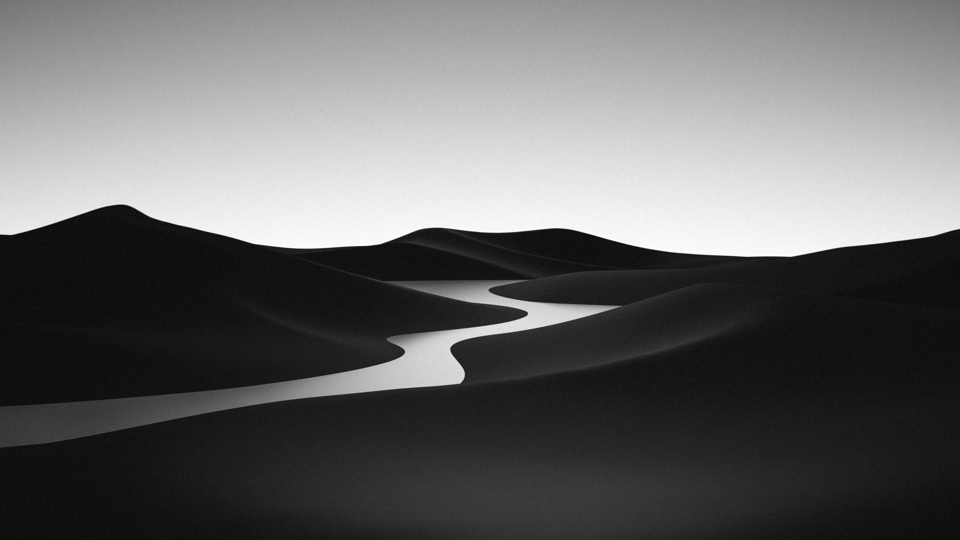

```json
{
  "prompt": "A serene and minimalist desert landscape. High-contrast black and white photograph featuring smooth, undulating sand dunes in deep, rich shadow, creating soft, organic silhouettes. A prominent, winding, S-shaped river or path, rendered in bright, luminous white, flows through the heart of the dark dunes, acting as a strong leading line and creating a stark contrast. The vast, clean sky is a soft grey-white, providing a tranquil backdrop. The lighting is soft and diffused, highlighting the graceful curves and volumes of the dunes with subtle, subtle gradients, avoiding harsh textures or strong cast shadows. The overall aesthetic is clean, abstract, and dreamlike, emphasizing form, contrast, and negative space.",
  "negative_prompt": "Color, vibrant, busy, chaotic, rocky, sharp textures, human, animals, complex details, city, buildings, distorted, noisy, grainy, blurry, low resolution, cluttered, jagged lines, excessive glare, muddy water, visible footprints, detailed sand grains, harsh direct sunlight.",
  "styles": ["minimalist photography", "abstract landscape", "high-contrast black and white", "fine art photography"],
  "aspect_ratio": "16:9",
  "parameters": {
    "cfg_scale": 7,
    "steps": 30,
    "sampler": "DPM++ 2M Karras"
  }
}
```

In [17]:
# start with producing a prompt description of image used previously
image = Image.open(img_path)
image.thumbnail([960,715])

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        image,
        "Generate a prompt style guide for the image attached, for a diffusion model to follow in the form of a json string output (not file), to create similar landscape images"
    ]
)

display(image)
Markdown(response.text)

In [18]:
prompt = """
{
  "prompt": "A minimalist black and white desert landscape. Smooth, undulating sand dunes in deep shadow, creating abstract, flowing forms. A bright, winding river or path cuts through the center, acting as a strong leading line, contrasting sharply with the dark dunes. The sky is a gradient of light grey to white, clear and expansive. High contrast, sharp focus throughout, serene, desolate, modern aesthetic, clean lines, cinematic.",
  "negative_prompt": "Cluttered, noisy, blurry, low resolution, harsh shadows, bright sunlight, rough texture, grainy, dull, messy, vegetation, trees, animals, people, buildings, colorful, vibrant, low contrast, distorted, cartoon, painting, drawing, bad composition, busy background, too much detail, realistic cracks, uneven horizon.",
  "aspect_ratio": "16:9",
  "style": [
    "minimalist",
    "abstract",
    "black and white photography",
    "monochromatic",
    "serene",
    "modern",
    "high contrast"
  ],
  "lighting": {
    "type": "Soft, diffused light",
    "direction": "Implied, creating subtle gradients and defined edges on dunes without harshness",
    "mood": "Calm, clear, ethereal"
  },
  "composition": {
    "subject": "Smooth sand dunes and a winding bright river/path",
    "foreground": "Dark, prominent dunes with the river beginning",
    "midground": "The S-shaped river snaking gracefully through the valleys of the dunes",
    "background": "Further receding dunes and a clean, gradient sky",
    "lines": "Strong leading lines formed by the river, organic curves of the dunes",
    "symmetry": "Asymmetrical but visually balanced",
    "depth_of_field": "Sharp focus from foreground to background",
    "perspective": "Slightly elevated eye-level view, wide shot capturing the expanse"
  },
  "color_palette": {
    "primary": "Deep blacks, bright whites, and smooth transitions of mid-grey",
    "contrast": "Very high contrast between the river and dunes",
    "mood": "Stark, elegant, clean"
  },
  "details": {
    "texture": "Extremely smooth, almost liquid-like surfaces for both dunes and river",
    "sharpness": "Crisp and well-defined edges on all forms",
    "clarity": "Exceptional clarity, no atmospheric haze or visual impurities",
    "form": "Abstract, sculptural forms created by the dunes"
  },
  "overall_mood": "Tranquil, contemplative, desolate, artistic, minimalist, powerful"
}
"""

I will generate a minimalist black and white image depicting a serene desert landscape. The focus will be on smooth, dark, undulating sand dunes creating abstract, flowing shapes. A sharply contrasting, bright, winding river will cut through the center, acting as a strong leading line. The sky will be a clear and expansive gradient from light grey to white. The image will have high contrast and sharp focus throughout, embodying a desolate yet modern aesthetic with clean lines and a cinematic feel.



image/png


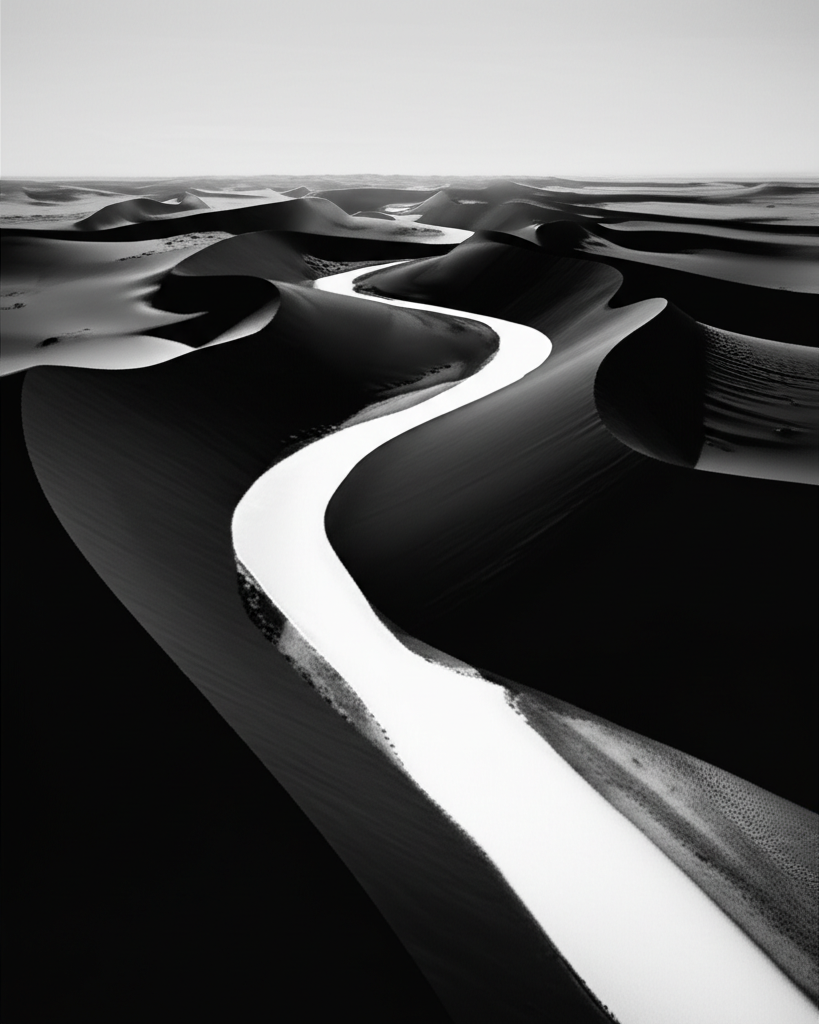

In [19]:
from IPython.display import Image, display, Markdown

# gemini image generation
response = client.models.generate_content(
    model="gemini-2.0-flash-preview-image-generation",
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=['Text','Image']
    )
)

for part in response.candidates[0].content.parts:
  if part.text is not None:
    display(Markdown(part.text))
  elif part.inline_data is not None:
    mime = part.inline_data.mime_type
    print(mime)
    data = part.inline_data.data
    display(Image(data=data))

* Alternative way to generate images:
  * [Imagen](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_imagen.ipynb)
    * [Documentation](https://www.google.com/url?q=https%3A%2F%2Fai.google.dev%2Fgemini-api%2Fdocs%2Fimage-generation%23choose-a-model)

## **Generate Content Stream**
* Stream response as it is being generated

In [20]:
for chunk in client.models.generate_content_stream(
    model=MODEL_ID,
    contents="""
    Write a 20 line haiku blog post based on a 1990s night in sapporo in the style of Murakami (book=After Dark)
    """
):
  print(chunk.text, end="")

## Midnight in Sapporo (1990s Haiku Drifts)

Neon bleeds the dark,
Sapporo breathes the night,
Ninety's quiet hum.

Cold rain on the glass,
Jazz notes from a distant bar,
Empty street reflects.

Late train sighs and stops,
Shadows walk, dissolved by light,
No one meets my gaze.

Cheap coffee burns tongue,
A girl flips through old magazine,
Fingers stained with ink.

Distant siren wails,
Muffled bass from basement club,
Heartbeat in the dark.

Warm ramen steam curls,
Sake warms the lonely throat,
Taste of the city.

Fluorescent lamp hums,
Casts long shadows on the wall,
Time feels very slow.

World spins outside pane,
I watch it without a thought,
Just observing now.

Suitcase by the door,
A payphone rings, then rings again,
No one picks it up.

Trumpet holds a note,
Fills the empty space with blue,
Memory floats free.

Wet asphalt reflects,
Headlights slice the misty air,
Endless street ahead.

Empty arcade glows,
Figures dance on faded screen,
Ghost of games long past.

Hours melt lik

## **Send asynchronous requests**

In [21]:
response = await client.aio.models.generate_content(
    model=MODEL_ID,
    contents="""
    Compose a sonnet about software engineering.
    """
)

Markdown(response.text)

From thought's abstract and formless, hazy dream,
The architect begins to sketch the plan,
A blueprint drawn where logic's lines will gleam,
As binary breathes life to mortal man.

With keyboard clack and monitor's soft glow,
A thousand lines, a complex web we weave,
Where data streams in ordered currents flow,
And hidden bugs the builder will deceive.

Then comes the crash, a cryptic, stark alarm,
The debugger's lamp, a guide through shadowed code,
We hunt the flaw that works our program harm,
Till clean compile lifts off the heavy load.

So from pure thought, a working marvel springs,
The silent force that moves the world on wings.

## **Functional Calling**
Allows the provision of a set of tools that it can use to respond to th e user's prompt.

* **Includes:**
  * The name of the function
  * The arguments to call it with

In [22]:
get_order = types.FunctionDeclaration(
    name = "get_order",
    description = "Get the online order specification of the user",
    parameters={
        "type": "OBJECT",
        "properties": {
            "online order": {
                "type": "STRING",
                "description": "The object that the user wishes to purchase online"
            },
        },
    },
)

order_tool = types.Tool(
    function_declarations=[get_order,]
)

response = client.models.generate_content(
    model=MODEL_ID,
    contents="""
    I need to order a dyson vacuum on Amazon.
    """,
    config=types.GenerateContentConfig(
        tools=[order_tool],
        temperature=0,
    ),
)

response.candidates[0].content.parts[0].function_call

FunctionCall(
  args={
    'online order': 'dyson vacuum on Amazon'
  },
  name='get_order'
)

## **Uploading & Processing Files** (Multi-modal)

### **Code Execution**
Allows the model to execute python code to answer complex questions.

In [23]:
from IPython.display import Image, Markdown, Code, HTML

response = client.models.generate_content(
    model=MODEL_ID,
    contents="""
    Generate a PEP-8 compliant python script to compute the famous fizzbuzz task.
    """,
    config = types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

for part in response.candidates[0].content.parts:
  if part.text is not None:
    display(Markdown(part.text))
  if part.executable_code is not None:
    code_html = f'<pre style="background-color: green;">{part.executable_code.code}</pre>'
    display(HTML(code_html))
  if part.code_execution_result is not None:
    display(Markdown(part.code_execution_result.output))
  if part.inline_data is not None:
    display(Image(data=part.inline_data.data, format="png"))



  display(Markdown("---"))

```python
def fizzbuzz(limit: int = 100) -> None:
    """
    Computes and prints the FizzBuzz sequence up to a specified limit.

    For each number from 1 to the limit (inclusive):
    - Prints "FizzBuzz" if the number is divisible by both 3 and 5.
    - Prints "Fizz" if the number is divisible by 3.
    - Prints "Buzz" if the number is divisible by 5.
    - Otherwise, prints the number itself.

    Args:
        limit (int): The upper limit (inclusive) for the FizzBuzz sequence.
                     Defaults to 100.
    """
    if not isinstance(limit, int) or limit < 1:
        raise ValueError("Limit must be a positive integer.")

    for i in range(1, limit + 1):
        # Check for divisibility by both 3 and 5 first
        if i % 15 == 0:  # Using 15 is equivalent to (i % 3 == 0 and i % 5 == 0)
            print("FizzBuzz")
        elif i % 3 == 0:
            print("Fizz")
        elif i % 5 == 0:
            print("Buzz")
        else:
            print(i)


if __name__ == "__main__":
    # Example usage: Run FizzBuzz up to 100
    print("--- FizzBuzz up to 100 ---")
    fizzbuzz()

    print("\n--- FizzBuzz up to 20 ---")
    fizzbuzz(20)

    # Example of handling potential errors (though the script doesn't take user input directly)
    try:
        print("\n--- Testing invalid input ---")
        fizzbuzz(0)
    except ValueError as e:
        print(f"Error: {e}")
```

---

### **Upload an Image File**

In [24]:
# prepare the file to be uploaded
IMG = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/black.jpg"
img_bytes = requests.get(IMG).content

img_path = pathlib.Path('black.png')
img_path.write_bytes(img_bytes)

2343619

In [25]:
# upload the file using the API
file_upload = client.files.upload(file=img_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Write a short melancholy journal entry from the perspective of a middle-aged Japanese journalist - from a Murakami Novel. Use a Header title",
    ]
)

Markdown(response.text)

## The Silent River, Or Something Like It

Another Tuesday. The rain started just after noon, a listless drizzle that seemed to have lost its way. I found myself staring at a digital photograph someone had sent – an abstract landscape, stark black and white. Dunes, obsidian dark, rising and falling like the slow, deep breaths of an ancient sleeper. And through them, a winding, luminous ribbon, a river of white, reflecting a sky that was neither day nor night.

It put me in a strange mood. Like trying to recall a dream that slips away the moment you try to grasp it. A landscape of absence, yet with a path clearly laid out. I wondered who created it, or if it simply... existed somewhere. A place you couldn't reach by train or plane, only by some forgotten turn in your own mind.

I brewed a fresh pot of coffee, the aroma momentarily pulling me back to the tangible world. Black, no sugar. The way I like my thoughts these days. This constant sifting through facts, writing about things that happen, things that break. Yet, my own life feels increasingly like those dark dunes – vast, silent, with no obvious destination for the shining river that cuts through it. Is the river leading somewhere, or merely reflecting the emptiness above? The subtle grain in the image, like the static clinging to old memories, or the low hum of the universe.

Tonight, I might just put on Coltrane, pour a glass of Suntory, and watch the rain fall. Or maybe I'll just sit here, letting the quiet expand, wondering if the river in that photograph ever finds the sea. Some questions have no answers, and perhaps, no one left to ask them.

### **Upload a Text File**
* Uploading a txt file from

In [26]:
# https://github.com/aaronhowellai/machine-learning-projects/blob/main/resources/example.txt

In [27]:
# prepare the file to be uploaded
TEXT = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/example.txt" # @param {type: "string"}
text_bytes = requests.get(TEXT).content

text_path = pathlib.Path('example.txt')
text_path.write_bytes(text_bytes)

59

In [28]:
# upload the text file using the API
file_upload = client.files.upload(file=text_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Please explain the content of this file and why it exists, and separate a line above that explanation with --------- printing the file content"
    ]
)

Markdown(response.text)

This is an example file for LLM APIs to download and view!
---------
**Explanation of the Content and Purpose:**

The content of this file is a single, self-referential sentence: "This is an example file for LLM APIs to download and view!"

This file exists primarily as a simple, illustrative example or a placeholder. Its purpose is to demonstrate or test the functionality of an LLM API (or any system designed to interact with files) in terms of:

1.  **Downloading:** Verifying that the API can successfully retrieve a file from a specified location.
2.  **Viewing/Reading:** Confirming that the API can access and display the content of a downloaded file.
3.  **Demonstration:** Providing a clear, non-complex example for developers or users to understand how file retrieval and content display works within an LLM's capabilities.
4.  **Testing:** Acting as a safe and predictable "dummy" file for automated tests of file handling features, ensuring the system can correctly process basic text content without complex parsing or security concerns.

In essence, it's a minimal, self-describing test case designed to confirm basic file interaction functionality.

### **Upload and Summarise a PDF File**
Using a pdf of the UK Government's AI Opportunities Action Plan: Government Response Policy published in the Department for Science, Innovation & Technology (DSIT)
* Download a PDF from a url and save it locally
* Upload the PDF file and generate a short summary of the PDF contents

In [29]:
PDF = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/AI%20Opportunities%20Action%20Plan_%20government%20response%20-%20GOV.UK.pdf" # @param {type: "string"}
pdf_bytes = requests.get(PDF).content

pdf_path = pathlib.Path('AI Opportunities Action Plan_ government response - GOV.UK.pdf')
pdf_path.write_bytes(pdf_bytes)

535811

In [30]:
# upload the file using the API
file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        """
        Please sumarise this PDF in 5 bullet points. Use a header-title. 2 newlines between each complete bullet section
        """
    ]
)

Markdown(response.text)

## UK AI Opportunities Action Plan: Government Response Summary

*   The UK government aims to establish the nation as an 'AI superpower' by leveraging Artificial Intelligence to transform public services, drive economic growth, and address societal challenges, as outlined in their 'Plan for Change'.


*   Key foundational investments include expanding sovereign compute capacity by at least 20x by 2030, establishing AI Growth Zones for data centers, and creating a National Data Library to unlock public sector data for research and innovation.


*   A strong focus is placed on building the AI talent pipeline through enhanced education pathways, scholarships, and initiatives to attract and retain world-class AI experts, ensuring the UK has the necessary skills.


*   The government is committed to enabling safe and trusted AI development by establishing a competitive regulatory regime, supporting and growing the AI Safety Institute (AISI) as a statutory body, and addressing copyright issues related to AI.


*   AI adoption across public services will follow a 'Scan, Pilot, Scale' approach, and a new government function will be created to partner with private sector AI companies, aiming to maximize the UK's stake in frontier AI and strengthen its global leadership.

### **Upload an Audio File**
Using one of my favourite remixed songs "[Testa Rossa Midnight Love](https://www.youtube.com/watch?v=pBX2T7R_DgY)" based on ""Midnight Pretenders" by an 80s Japanese singer Tomoko Aran".

* Download and upload the file
* Analyse the melodic patterns, tone and feel of the song, and write a 10 line haiku based on it.

In [31]:
import IPython.display as ipd

# audio path
url = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/Testa%20Rossa%20Midnight%20Love.mp3"
ipd.Audio(url=url)

In [32]:
AUDIO = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/Testa%20Rossa%20Midnight%20Love.mp3"
audio_bytes = requests.get(AUDIO).content

audio_path = pathlib.Path('Testa Rossa Midnight Love.mp3')
audio_path.write_bytes(audio_bytes)


4104612

In [33]:
# upload and analyse the file using the API
file_upload = client.files.upload(file=audio_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "You are an 80s Tokyo-based novelist, and happen to hear this song attached play on the radio after 10pm in a bar. Listen carefully and Analyse the melodic patterns, tone and feel of the song, and write a 10 line haiku based on it. Make a header title too for the haiku."
    ]
)

Markdown(response.text)

### Tokyo Neon Pulse

Tokyo night falls,
Neon bleeds on the pane.
Synth notes gently hum,
A voice so soft, longing.

Rhythm starts to sway,
Through the bar's smoky air.
Ice clinks, quiet sighs,
Dreams woven in electric threads.

City's quiet heart,
Beats on in the twilight.

### **Process a YouTube Link** (Computer Vision)
* More on [Computer Vision](https://ai.google.dev/gemini-api/docs/image-understanding?lang=python#youtube) with the Gemini API

In [34]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents= types.Content(
        parts=[
            types.Part(text="Shortly Summarise this video."),
            types.Part(
                file_data=types.FileData(file_uri="https://www.youtube.com/watch?v=pBX2T7R_DgY")
            )
        ]
    )
)

Markdown(response.text)

This video showcases a Japanese schoolgirl in a sailor uniform who uses a bladed yoyo as a unique weapon. It features stylized combat against other girls, battling bullies and injustice, interspersed with moments of friendship and empowerment.

### **URL Context**
* **URL Context Tool:** A powerful component in enabling dynamic agentic workflows
  * Allows a Gemini model to process and understand the contents of any URL and report back to the user about it.

In [35]:
prompt = """
Explain the content on this link is found to be entertaining by "fans" https://www.formula1.com/en/latest/article/its-time-to-basically-stop-all-the-rumours-verstappen-confirms-hes-staying.2xjitPqnx2kg3bw89Pvo76. Use a "###" Markdown title. Use one small paragraph
"""

tools = []
tools.append(types.Tool(urlContext=types.UrlContext))

client = genai.Client(api_key=GEMINI_API_KEY)
config = types.GenerateContentConfig(
    tools=tools,
)

response = client.models.generate_content(
    contents=[prompt],
    model=MODEL_ID,
    config=config
)

Markdown(response.text)

### Verstappen Confirms Red Bull Stay

Fans would find the content on this link entertaining because it definitively addresses the long-standing rumors surrounding Max Verstappen's future in Formula 1. The article confirms that Verstappen will remain with Red Bull for the 2026 season, putting an end to speculation that he might join Mercedes. This clear statement from the reigning World Champion himself provides closure and certainty for fans who have been following the driver market closely, alleviating concerns about a potential team change and allowing them to focus on the current and upcoming seasons with a clear understanding of Verstappen's commitment to Red Bull.